# Visualizing the Evolution of a Gel's Shape Over Time

In this experimental setup, the borders of the gel are catenary or catenary-like curves. One way to measure how a gel's shape changes over time, in varying conditions, is to measure how these curves change. 

The midordinate is the distance between the curve's 2 endpoints and its maximum/minimum point and it is perpendicular to the tangent at this extrema. As the gel's shape changes, the curve becomes more concave or more convex and so the midordinate's length changes.

Here, a curve is considered to be concave if it is bends inwards and concave if it bends outwards, regardless of whether it is the upper or lower curve.

The Excel file's expected organization is as follows :

| Condition | Sample | Curve | 0 hrs | 1 hrs | ... | n hrs |
| :-: | :-: | :-: | :-: | :-: | :-: | :-: |
| A | 1 | upper | 0 | 0.001 | ... | 100 |
| A | 1 | lower | 0 | 0.002 | ... | 200 |
| A | 2 | upper | 0 | 0.003 | ... | 300 |
| ... | ... | ... | ... | ... | ... | ... | ... |
| B | 1 | lower | 0 | 0.004 | ... | 400 |
| ... | ... | ... | ... | ... | ... | ... |

When recording measurements, all distances should be positive, regardless of whether it starts or becomes concave or convex.

It is important to know whether the gel is initially concave or convex for proper interpretation!

Say that all gels start concave. Increasing lengths indicate that the gels become more concave while decreasing lengths indicate that they become more convex.

In [23]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams.update({'font.size': 15})

In [24]:
df = pd.read_excel("../data/gel_shape_evolution.xlsx") # replace as needed

conditions = df["Condition"].unique()
df.set_index(["Condition", "Sample", "Curve"], inplace=True)
df.dropna(axis=0, how="all", inplace=True)

conversion_ratio = 1 # convert between pixels and μm
df = df / conversion_ratio

display(df)

0 hrs     1 hrs     2 hrs     3 hrs     4 hrs  \
Condition Sample Curve                                                  
A         1      upper    0.0  0.045000  1.235000  1.571000  1.743000   
                 lower    0.0  0.641000  0.485000  1.110000  1.786000   
          2      upper    0.0  0.018000  1.052000  1.489000  1.368000   
                 lower    0.0  0.336000  1.002000  1.061000  1.094000   
B         1      upper    0.0 -0.771881 -0.619739 -0.228490 -0.752922   
                 lower    0.0 -0.118346 -0.301374 -0.191780 -0.653627   
          2      upper    0.0 -0.444253 -0.945238 -0.872958 -0.988382   
                 lower    0.0 -0.423361 -0.954478 -0.256617 -0.198475   

                           5 hrs     6 hrs     7 hrs     8 hrs     9 hrs  ...  \
Condition Sample Curve                                                    ...   
A         1      upper  2.202000  2.302000  1.865000  2.075000  2.816000  ...   
                 lower  1.448000  2.290000  1.688000  2.737000  2.377000  ...   
          2      upper  1.562000  1.608000  2.353000  2.470000  2.185000  ...   
                 lower  1.416000  1.924000  1.693000  2.568000  2.074000  ...   
B         1      upper -0.239937 -0.959295 -0.413997 -0.760107 -0.639669  ...   
                 lower -0.992132 -0.910193 -0.340469 -0.808791 -0.625306  ...   
          2      upper -0.973529 -0.827299 -0.248975 -1.074743 -0.747149  ...   
                 lower -0.674547 -0.345610 -0.580818 -0.136023 -0.420525  ...   

                          40 hrs    41 hrs    42 hrs    43 hrs    44 hrs  \
Condition Sample Curve                                                     
A         1      upper  6.052000  6.351000  5.534000  5.767000  5.731000   
                 lower  5.973000  6.165000  6.339000  6.279000  6.260000   
          2      upper  5.583000  6.028000  5.764000  5.892000  5.762000   
                 lower  6.287000  5.555000  6.462000  6.106000  5.729000   
B         1      upper -0.892982 -0.929564 -1.174541 -1.344491 -0.604550   
                 lower -1.198247 -1.071455 -1.189205 -0.929286 -0.966168   
          2      upper -1.218301 -0.496717 -0.979105 -0.876225 -1.073217   
                 lower -0.526239 -0.615046 -1.007266 -0.823728 -1.333020   

                          45 hrs    46 hrs    47 hrs    48 hrs    49 hrs  
Condition Sample Curve                                                    
A         1      upper  6.397000  6.314000  6.313000  6.598000  6.616000  
                 lower  6.207000  6.291000  5.859000  6.597000  6.989000  
          2      upper  6.650000  5.890000  6.070000  6.754000  6.066000  
                 lower  6.461000  6.338000  6.847000  6.536000  6.402000  
B         1      upper -1.107661 -0.905864 -0.807886 -1.163110 -1.256967  
                 lower -0.885812 -1.374034 -1.349315 -0.889051 -1.034614  
          2      upper -1.129764 -0.709719 -0.526451 -1.373546 -0.847166  
                 lower -0.895620 -0.722790 -1.284644 -1.245797 -0.593665  

[8 rows x 50 columns]

In [25]:
time = [int(t.split(" ")[0]) for t in df.columns]

In [26]:
# calculate differences between t_0 and t_n
diffs = {c: {t:[] for t in time} for c in conditions}
for i in range(df.shape[0]) :
    sample = df.iloc[i]
    c = sample.name[0]

    init = sample["0 hrs"]
    for t in time :
        diffs[c][t].append(sample[f"{t} hrs"] - init)

In [27]:
# calculate mean differences and standard deviations at each time point
means = {c : {t:np.mean(lst) for t,lst in val.items()} for c,val in diffs.items()}

stds = {c : {t:np.std(lst) for t, lst in val.items()} for c,val in diffs.items()}

In [28]:
# assign colors to each condition 
cmap = mpl.colormaps["plasma"]
colors = list(cmap(np.linspace(start=0, stop=0.9, num=len(conditions))))
condition_colors = {conditions[i]:colors[i] for i in range(len(conditions))}

# (!) for mock data with only 2 conditions, remove as needed
colors = list(cmap(np.linspace(start=0, stop=0.9, num=4)))
condition_colors = {"A":colors[0], "B":colors[2]}

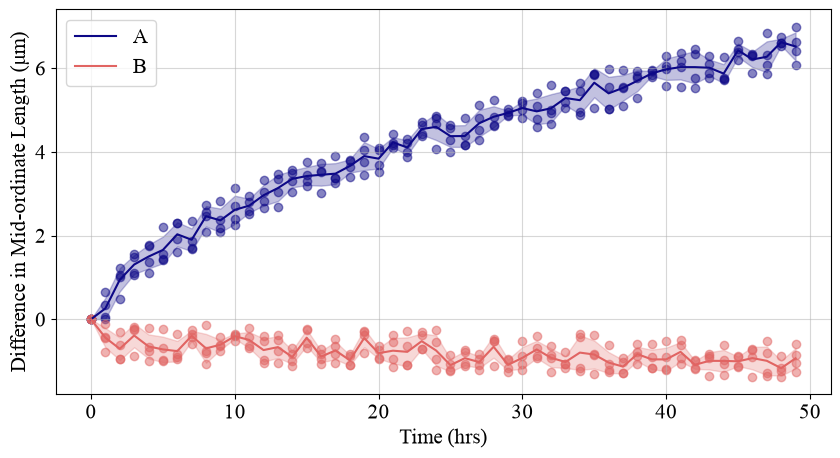

In [29]:
# graphing
fig = plt.figure(figsize=(10, 5))

for c in conditions :
    diffs_i = diffs[c]; means_i = means[c]; 
    means_val = np.array(list(means_i.values())); stds_val = np.array(list(stds[c].values()))

    tps = []
    for t in time :
        tps += [t] * len(diffs_i[0])

    # plot individual data points
    plt.scatter(tps, diffs_i.values(), color=condition_colors[c], alpha=0.5)

    # plot mean of each condition
    plt.plot(means_i.keys(), means_val, color=condition_colors[c])

    # cover standard deviation
    plt.fill_between(
        means_i.keys(),
        means_val - stds_val,
        means_val + stds_val,
        color=condition_colors[c],
        alpha=0.25
    )

# add labels for each condition, avoid repeats
for c1, c2 in condition_colors.items() :
    plt.plot(0,0, color=c2, label=c1)

plt.xlabel("Time (hrs)")
plt.ylabel("Difference in Mid-ordinate Length (μm)")

plt.grid(alpha=0.5)
plt.legend()
plt.show()

The graph shows the change in the the midordinate's initial length ($t_{0}$) and its lengths at $t_{n}$.

***

Admittedly, it could be more interesting to define concavity and convexity as positive and negative, respectively or vice versa, to immediately see whether a gel in a certain condition is initially concave or convex. That way, 0 would represent a horizontally straight border and the concave-convex transition point.

However, based on experience with this setup, all gels have started as concave.